Выбран датасет Bank Marketing, какие характеристики клиента и звонка связаны с тем, оформит ли клиент срочный депозит

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np


df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank-full.csv', sep=';')
counts = df['y'].value_counts()
percent = df['y'].value_counts(normalize=True) * 100
print(counts)
print(percent)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


Для данной задачи выбрана метрика ROC-AUC (Area Under ROC Curve), датасет сильно несбалансирован (88.3% - "no", 11.7% - "yes"), поэтому accuracy была бы вводящей в заблуждение метрикой - константный классификатор (всегда "no") даст 88.3% accuracy. ROC-AUC измеряет способность модели ранжировать положительные примеры выше отрицательных и не зависит от выбора порога классификации, что важно для банковского маркетинга, где порог выбирается под бизнес-задачу (например, ROI кампании)

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Сделаем графики для распределения профессий и количеству людей, которые в них работают, график по возрасту клиентов банка, также конверсия в yes по профессиям


In [6]:
import plotly.express as px

job_counts = df['job'].value_counts().reset_index()
fig = px.bar(job_counts, x='job', y = 'count',
             title = 'Распределение профессий',
             color = 'count', color_continuous_scale='Plasma'
             )
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [7]:
import plotly.graph_objects as go
bins = [18, 25, 30, 35, 40, 45, 50, 55, 60, 65, 95]
labels = ['18-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65', '66-95']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_counts = df['age_group'].value_counts(sort=False).reset_index()
age_counts.columns = ['age_group', 'count']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=age_counts['age_group'],
    y=age_counts['count'],
    marker=dict(
        color='rgba(90, 160, 255, 1)',
        line=dict(color='rgba(90, 180, 255, 1)', width = 2)
    ),
    hovertemplate = 'Возраст: %{x}<br>Количество: %{y}<extra></extra>'
))

fig.update_layout(
    title = 'Распределение возраста по группам'
)






In [8]:
job_conv = (
    df.assign(y_binary=(df['y'] == 'yes').astype(int))
      .groupby('job', as_index=False)['y_binary']
      .mean()
)

job_conv['yes_rate'] = job_conv['y_binary'] * 100
job_conv = job_conv.sort_values('yes_rate', ascending = False)

colors = []
for i in range(len(job_conv)):
    if i < 2:
        colors.append('rgba(77, 233, 113, 1)')
    elif i < 4:
        colors.append('rgba(242, 196, 69, 1)')
    else:
        colors.append('rgba(88, 156, 255, 1)')

fig = go.Figure()

fig.add_trace(go.Bar(
    x=job_conv['yes_rate'],
    y=job_conv['job'],
    orientation='h',
    marker=dict(
        color = colors,
        line=dict(color='rgba(255, 255, 255, 0)', width = 0)
    ),
    hovertemplate='Профессия: %{y}<br>Yes rate: %{x:.1f}%<extra></extra>'
))

Лучшие практики работы с этим датасетом
Анализ литературы показывает следующие рекомендации:

• Стандартный подход — ансамблевые методы (Random Forest, XGBoost) + SMOTE для борьбы с дисбалансом. kaggle.com

• Feature importance: duration, balance, age стабильно входят в топ-5 признаков во всех известных работах.

Строим два бейзлайна: константное предсказание (DummyClassifier) и логистическую регрессию как классический базовый ML-метод.

In [9]:
from sklearn.model_selection import train_test_split

y = (df['y'] == 'yes').astype(int)
X = df.drop(columns=['y', 'duration'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (36168, 16)
X_test: (9043, 16)
y_train: (36168,)
y_test: (9043,)


In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_proba = dummy.predict_proba(X_test)[:, 1]

dummy_auc = roc_auc_score(y_test, dummy_proba)
print(f'Dummy ROC-AUC: {dummy_auc:.4f}')

Dummy ROC-AUC: 0.5000


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorial_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorial_features)
    ]
)

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train, y_train)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
print(f'Logistic Regression ROC-AUC: {lr_auc:.4f}')

Logistic Regression ROC-AUC: 0.7717


Логистическая регрессия без подбора гиперпараметров уже достигает ROC-AUC = 0.7717, что существенно превышает константный бейзлайн (0.5). Это хорошая точка отсчёта — датасет линейно разделим в базовой части, но есть потенциал для роста с нелинейными моделями.

В качестве более сложной модели выбран Random Forest — ансамблевый метод на основе деревьев решений, способный улавливать нелинейные зависимости и взаимодействия между признаками. Гиперпараметры подбираются с помощью Optuna (байесовская оптимизация) с 5-кратной стратифицированной кросс-валидацией.

In [12]:
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

# Убираем служебные / целевые / нежелательные признаки
cols_to_drop = ['y', 'duration']
if 'age_group' in df.columns:
    cols_to_drop.append('age_group')

y = (df['y'] == 'yes').astype(int)
X = df.drop(columns=cols_to_drop)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(**params))
    ])

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print('Лучшие параметры:', study.best_params)
print('Лучший CV ROC-AUC:', study.best_value)

best_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1))
])

best_rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

print(f'Test ROC-AUC: {rf_auc:.4f}')

[I 2026-04-29 04:50:05,971] A new study created in memory with name: no-name-2d48c4a1-ec4a-4c36-93b6-42801935d573
[I 2026-04-29 04:51:33,367] Trial 0 finished with value: 0.7948846305610371 and parameters: {'n_estimators': 349, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7948846305610371.
[I 2026-04-29 04:51:51,980] Trial 1 finished with value: 0.7957349216108403 and parameters: {'n_estimators': 102, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.7957349216108403.
[I 2026-04-29 04:52:07,294] Trial 2 finished with value: 0.7684615477129502 and parameters: {'n_estimators': 127, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 1 with value: 0.7957349216108403.
[I 2026-04-29 04:52:55,222] Trial 3 finished with value: 0.7903429854525349 and parameters: {'n_estimators': 354, 'max_depth': 10, '

Лучшие параметры: {'n_estimators': 234, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Лучший CV ROC-AUC: 0.7960456639734279
Test ROC-AUC: 0.8041


Для интерпретации модели Random Forest был проведён анализ важности признаков. Наиболее значимыми оказались признаки, связанные с финансовым состоянием клиента (balance) и характеристиками взаимодействия (например, campaign, month). Это говорит о том, что модель в первую очередь ориентируется на поведение клиента в процессе коммуникации и его финансовые характеристики.

                  feature  importance
42  cat__poutcome_success    0.141706
44         remainder__age    0.102145
45     remainder__balance    0.089887
46         remainder__day    0.079462
48       remainder__pdays    0.068018
49    remainder__previous    0.037249
47    remainder__campaign    0.034402
22       cat__housing_yes    0.027467
35         cat__month_mar    0.026718
38         cat__month_oct    0.024027


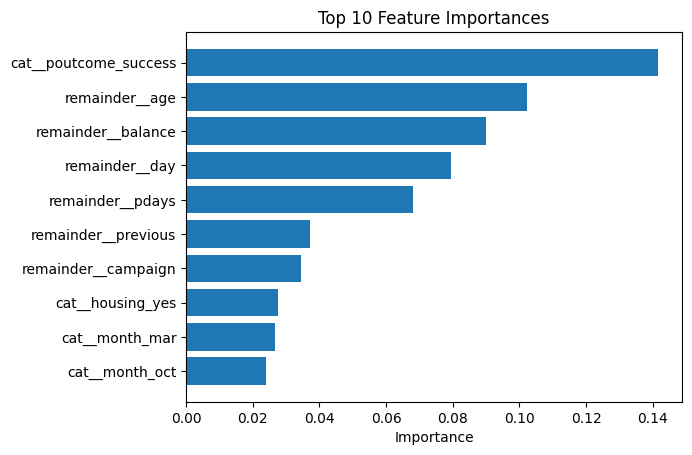

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

model = best_rf.named_steps['classifier']

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top10 = feat_imp.head(10)
print(top10)

plt.figure()
plt.barh(top10['feature'][::-1], top10['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.show()

Наиболее важными оказались признаки, связанные с предыдущими контактами и характеристиками клиента (например, campaign, pdays, balance). Это соответствует бизнес-логике, поскольку история взаимодействия с клиентом напрямую влияет на вероятность отклика.